In [1]:
# ── Core ──
import numpy as np
import pandas as pd
import xarray as xr
import dask
from dask.diagnostics import ProgressBar
import zarr
import fsspec
import os
import re
from collections import defaultdict
import zarr

# ── Statistics ──
from scipy.stats import linregress
from scipy.ndimage import gaussian_filter, gaussian_filter1d

# ── Visualisation ──
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.animation as animation
from matplotlib.colors import LogNorm, SymLogNorm
from IPython.display import HTML
import seaborn as sns

# ── Cartopy ──
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Data Loading

In [2]:
# Load the ocean mask
mask=xr.open_dataset('/network/group/aopp/predict/AWH020_AYIM_EXTREME/mask_ocean.nc').topo

In [3]:
# JJA reforecast
jja_data = xr.open_zarr('/network/group/aopp/predict/MRA001_AYIM_REFORCST/full_refore.zarr')

# DJF reforecast (Dec + Jan/Feb combined)
dec_jan_feb = xr.open_zarr('/network/group/aopp/predict/MRA001_AYIM_REFORCST/full_djf_reforecast.zarr')

# December-only reforecast (for DJF year 2001 special case)
prev_dec_data = xr.open_zarr('/network/group/aopp/predict/MRA001_AYIM_REFORCST/full_dec_reforecast.zarr')

In [4]:

zarr.consolidate_metadata(
    "/home/a/ayim/MAN/Extreme_temperature_and_financial_markets/data/processed/climatologies/tmax_95th_pctl_doy_nh_jja_global_1990_2020_025deg.zarr"
)
zarr.consolidate_metadata(
    "/home/a/ayim/MAN/Extreme_temperature_and_financial_markets/data/processed/climatologies/tmax_95th_pctl_doy_sh_djf_1990_2020_025deg.zarr/"
)
thresh_nh=xr.open_zarr("/home/a/ayim/MAN/Extreme_temperature_and_financial_markets/data/processed/climatologies/tmax_95th_pctl_doy_nh_jja_global_1990_2020_025deg.zarr")
thresh_sh=xr.open_zarr("/home/a/ayim/MAN/Extreme_temperature_and_financial_markets/data/processed/climatologies/tmax_95th_pctl_doy_sh_djf_1990_2020_025deg.zarr")

# Helper Functions

In [ ]:
#read the txt file
rgb_data_in_the_txt_file = np.loadtxt("/home/a/ayim/new_project/personal_cmaps/misc_div.txt")

#create the colormap
my_colormap = mcolors.LinearSegmentedColormap.from_list('colormap', (rgb_data_in_the_txt_file/255))

def fix_lonlat(da):
    """Convert 0–360 longitudes to −180–180 and ensure ascending lat/lon."""
    for lon_name in ["lon", "longitude"]:
        if lon_name in da.coords:
            lon = da[lon_name]
            if lon.max() > 180:
                da = da.assign_coords({lon_name: ((lon + 180) % 360) - 180})
            da = da.sortby(lon_name)
    return da


def subset_region(da, lat_min, lat_max, lon_min, lon_max):
    """Subset DataArray/Dataset by lat/lon bounds; robust to axis order and domain."""
    lat_name = "latitude" if "latitude" in da.dims else "lat"
    lon_name = "longitude" if "longitude" in da.dims else "lon"

    lat0, lat1 = (lat_max, lat_min) if da[lat_name].values[0] > da[lat_name].values[-1] else (lat_min, lat_max)
    lon_vals = da[lon_name].values
    lo, hi = lon_min, lon_max

    if lon_vals.min() >= 0 and lon_vals.max() <= 360:
        if lo < 0: lo += 360
        if hi < 0: hi += 360
    else:
        if lo > 180: lo -= 360
        if hi > 180: hi -= 360

    if lo <= hi:
        parts = [da.sel({lat_name: slice(lat0, lat1), lon_name: slice(lo, hi)})]
    else:
        if lon_vals.min() >= 0:
            parts = [da.sel({lat_name: slice(lat0, lat1), lon_name: slice(0, hi)}),
                     da.sel({lat_name: slice(lat0, lat1), lon_name: slice(lo, 360)})]
        else:
            parts = [da.sel({lat_name: slice(lat0, lat1), lon_name: slice(-180, hi)}),
                     da.sel({lat_name: slice(lat0, lat1), lon_name: slice(lo, 180)})]

    return xr.concat(parts, dim=lon_name) if len(parts) > 1 else parts[0]


def draw_box_on_map(ax, lat1, lon1, lat2, lon2, color):
    """Draw a lat/lon rectangle on a cartopy axis."""
    rect = mpatches.Rectangle(
        (lon1, lat1), lon2 - lon1, lat2 - lat1,
        linewidth=2, edgecolor=color, facecolor='none',
        transform=ccrs.PlateCarree()
    )
    ax.add_patch(rect)


def assign_season_year_safe(time):
    """Assign DJF/MAM/JJA/SON season labels, rolling December into the next year."""
    month = time.dt.month
    year  = time.dt.year
    season = xr.where(month.isin([12,1,2]), 'DJF',
             xr.where(month.isin([3,4,5]),  'MAM',
             xr.where(month.isin([6,7,8]),  'JJA',
             xr.where(month.isin([9,10,11]),'SON', 'NA'))))
    season_year = xr.where(month == 12, year + 1, year)
    labels = np.core.defchararray.add(season.values.astype(str), '-')
    labels = np.core.defchararray.add(labels, season_year.values.astype(str))
    return xr.DataArray(labels, coords=[time], dims=["time"])


def calculate_magnitudes_and_return_periods(data):
    sorted_data = np.sort(data)
    probs = 1 - (np.arange(len(data)) / len(data))
    return sorted_data, probs


def compute_slope(data):
    """Fit exponential tail to top-5% of data; return e-folding scale."""
    if np.all(np.isnan(data)):
        return np.nan
    data = data - np.nanmean(data)
    top = data[data >= np.nanpercentile(data, 95)]
    if top.size < 10:
        return np.nan
    mags, probs = calculate_magnitudes_and_return_periods(top)
    try:
        log_probs = np.log(np.clip(probs, 1e-8, 1))
        coeff = np.polyfit(mags, log_probs, 1)
        slope = 1 / np.exp(coeff[0])
        return slope if np.isfinite(slope) else np.nan
    except Exception:
        return np.nan


def compute_slope_and_stderr(data):
    """Fit exponential tail to top-5%; return (e-folding scale, SE via delta method)."""
    if np.all(np.isnan(data)):
        return np.nan, np.nan
    data = data - np.nanmean(data)
    top = data[data >= np.nanpercentile(data, 95)]
    if top.size < 10:
        return np.nan, np.nan
    mags, probs = calculate_magnitudes_and_return_periods(top)
    try:
        log_probs = np.log(np.clip(probs, 1e-8, 1))
        coeff, cov = np.polyfit(mags, log_probs, 1, cov=True)
        slope = 1 / np.exp(coeff[0])
        if not np.isfinite(slope):
            return np.nan, np.nan
        se_slope = np.sqrt(cov[0, 0]) * np.abs(slope)
        return slope, se_slope
    except Exception:
        return np.nan, np.nan


def compute_linregress_simple(temp_data, prob_data):
    """Pointwise OLS regression of log-exceedance probability on temperature anomaly."""
    def _wrapper(x, y):
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() > 1:
            res = linregress(x[mask], y[mask])
            return res.slope, res.pvalue, res.stderr
        return np.nan, np.nan, np.nan

    slope, p_value, stderr = xr.apply_ufunc(
        _wrapper, temp_data, prob_data,
        input_core_dims=[["hDate"], ["hDate"]],
        output_core_dims=[[], [], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float, float, float]
    )
    return xr.Dataset({"slope": slope, "p_value": p_value, "stderr": stderr})


def gaussian_filter_nan(data, sigma):
    """Gaussian filter that preserves NaNs."""
    nan_mask = np.isnan(data)
    filtered = gaussian_filter(np.nan_to_num(data), sigma=sigma)
    filtered[nan_mask] = np.nan
    return filtered


def plot_sensitivity_map(da, ticks, labels, vmin=0.5, vmax=10, cmap="viridis", save_path=None):
    """Plot a global sensitivity map with log-normalised colorbar."""
    norm = mcolors.LogNorm(vmin=vmin, vmax=vmax, clip=True)
    fig, ax = plt.subplots(
        figsize=(10, 5),
        subplot_kw={"projection": ccrs.Robinson(central_longitude=0)}
    )
    im = da.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(),
        norm=norm, cmap=cmap,
        add_colorbar=False, shading="auto", rasterized=True
    )
    ax.coastlines()
    ax.add_feature(cfeature.LAND,      facecolor="none")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, alpha=0.4)
    ax.set_title("")

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = gl.ylabel_style = {"size": 9}

    cax = fig.add_axes([0.13, 0.02, 0.74, 0.045])
    cbar = fig.colorbar(im, cax=cax, orientation="horizontal", extend="max")
    cbar.set_ticks(ticks)
    cbar.ax.minorticks_off()
    cbar.set_ticklabels(labels)
    cbar.set_label("Factor (Change in Probability per 1°C)")

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()

# JJA Analysis

In [6]:
data = jja_data.load()
mask = fix_lonlat(mask)

# Pool members and initial dates → (hDate, latitude, longitude, dim)
pooled_members = data["t2m"].stack(dim=["inidate", "number"])

# Match ERA5 threshold to each ensemble member by day-of-year
inidate_from_dim = pooled_members.indexes["dim"].get_level_values("inidate")
doy_from_dim     = inidate_from_dim.dayofyear.astype(int)

thresh_matched = thresh_nh.sel(
    dayofyear=xr.DataArray(doy_from_dim, dims="dim")
).drop_vars("dayofyear")["thresh"]

thresh_np = thresh_matched.values.transpose(1, 2, 0)[np.newaxis, :, :, :]

# Exceedance probability per year
exceedances             = pooled_members >= thresh_np
prob_exceedance_per_year = exceedances.mean(dim="dim")

prob_ex = prob_exceedance_per_year.where(mask == 1, drop=True)
log_prob_exceedance_per_year = np.log(prob_ex)
print("JJA exceedance probability computed.")
print(prob_exceedance_per_year)

JJA exceedance probability computed.
<xarray.DataArray 't2m' (hDate: 20, latitude: 721, longitude: 1440)>
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,


/home/a/ayim/miniforge3/envs/cmip-env/lib/python3.10/site-packages/xarray/core/computation.py:822: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


In [7]:
# Upper-tail slope map (land only)
masked_ref = data.stack(dim=["hDate", "inidate", "number"]).where(fix_lonlat(mask) == 1, drop=True)

with ProgressBar():
    slope_jja, se_jja = xr.apply_ufunc(
        compute_slope_and_stderr,
        masked_ref.t2m.compute(),
        input_core_dims=[["dim"]],
        output_core_dims=[[], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float, float]
    )

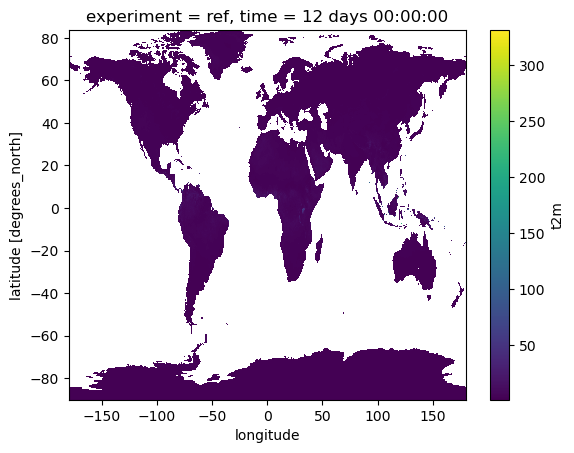

In [8]:
slope_jja.plot()

In [9]:
# Gaussian smoothing (200 km) + interannual regression
R_KM = 200
da = pooled_members

da2 = da.mean(dim="dim")   # mean over members → (hDate, lat, lon)
lat_name = [d for d in da2.dims if "lat" in d.lower()][0]
lon_name = [d for d in da2.dims if "lon" in d.lower()][0]
hdate_name = [d for d in da2.dims if d not in (lat_name, lon_name)][0]

lat      = da2[lat_name].values
lon      = da2[lon_name].values
grid_deg = float(np.abs(lat[1] - lat[0]))

sigma_lat_cells = (R_KM / 110.574) / grid_deg
lat_rad         = np.deg2rad(lat)
coslat          = np.clip(np.cos(lat_rad), 0.05, 1.0)
sigma_lon_cells = np.minimum((R_KM / (111.320 * coslat)) / grid_deg,
                              max(3.0 * sigma_lat_cells, 200.0))

n_h, nlat, nlon = da2.sizes[hdate_name], da2.sizes[lat_name], da2.sizes[lon_name]
out = np.full((n_h, nlat, nlon), np.nan, dtype=da2.dtype)

for idx in range(n_h):
    arr    = da2.isel({hdate_name: idx}).values
    sm_lat = gaussian_filter1d(arr, sigma=sigma_lat_cells, axis=0, mode="nearest")
    smoothed = np.empty_like(sm_lat)
    for i in range(nlat):
        smoothed[i, :] = gaussian_filter1d(sm_lat[i, :], sigma=float(sigma_lon_cells[i]), mode="wrap")
    out[idx] = smoothed

filtered = xr.DataArray(
    out,
    coords={hdate_name: da2.coords[hdate_name],
            lat_name:   da2.coords[lat_name],
            lon_name:   da2.coords[lon_name]},
    dims=(hdate_name, lat_name, lon_name),
    name=f"t2m_smoothed_{R_KM}km"
)
climatology   = filtered.mean(dim="hDate")
jja_smoothed_anom = filtered - climatology
print(f"Gaussian smoothing complete at R={R_KM} km.")

Gaussian smoothing complete at R=200 km.


In [10]:
# Interannual regression: log P(exceedance) ~ smoothed T2m anomaly
smoothed_land = jja_smoothed_anom.where(mask == 1, drop=True)
a, b = xr.align(smoothed_land, log_prob_exceedance_per_year, join="inner", copy=False)

jja_reg     = compute_linregress_simple(a, b)
slope_sig   = jja_reg.slope.where(jja_reg.p_value <= 0.05)
jja_stderr  = jja_reg.stderr.where(jja_reg.p_value <= 0.05)

/home/a/ayim/miniforge3/envs/cmip-env/lib/python3.10/site-packages/xarray/core/computation.py:822: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)


Saved: /home/a/ayim/MAN/Extreme_temperature_and_financial_markets/data/slopes/jja_rr_per_degC_200km_era5clim_2001_2020_025deg.pdf


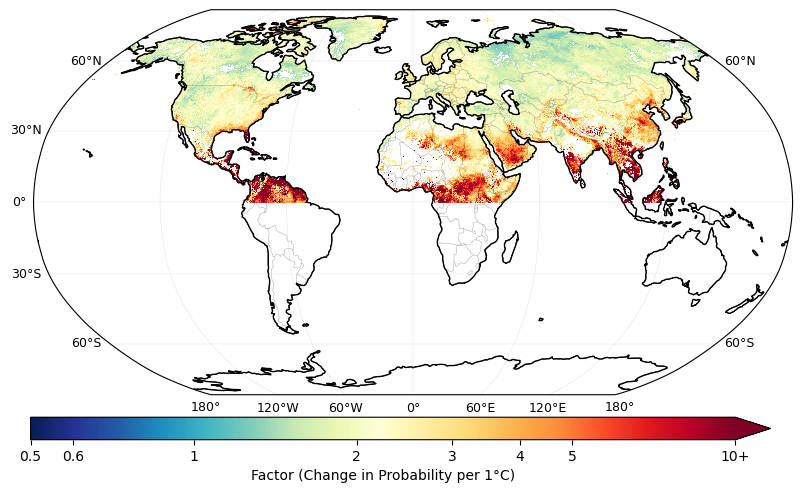

Saved: /home/a/ayim/MAN/Extreme_temperature_and_financial_markets/data/slopes/jja_stderr_per_degC_200km_era5clim_2001_2020_025deg.pdf


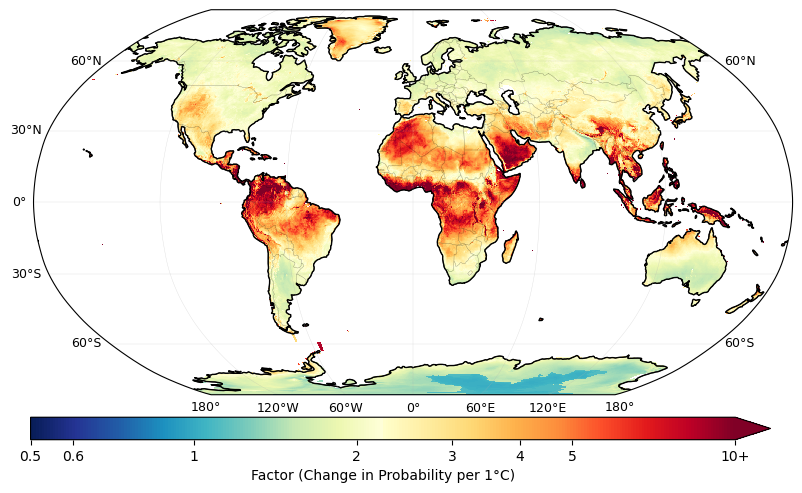

In [11]:
# Save JJA RR map
ticks  = [0.5, 0.6, 1, 2, 3, 4, 5, 10]
labels = ["0.5", "0.6", "1", "2", "3", "4", "5", "10+"]

plot_sensitivity_map(
    np.exp(slope_sig), ticks, labels, cmap=my_colormap,
    save_path="/home/a/ayim/MAN/Extreme_temperature_and_financial_markets/data/slopes/"
              "jja_rr_per_degC_200km_era5clim_2001_2020_025deg.pdf"
)

plot_sensitivity_map(
    slope_jja, ticks, labels, cmap=my_colormap,
    save_path="/home/a/ayim/MAN/Extreme_temperature_and_financial_markets/data/slopes/"
              "jja_stderr_per_degC_200km_era5clim_2001_2020_025deg.pdf"
)

# DJF Analysis

In [ ]:
# Load only the small prev_dec dataset (just 1 hDate)
with ProgressBar():
    prev_dec_data = prev_dec_data.load()
prev_dec_data = fix_lonlat(prev_dec_data)

# Keep dec_jan_feb lazy — slice per year, concat, then load once at the end
djf_list = []
for year in range(2001, 2021):
    print(f"Building DJF {year}...")

    janfeb = fix_lonlat(
        dec_jan_feb["t2m"].sel(
            hDate=year,
            inidate=dec_jan_feb.inidate[dec_jan_feb.inidate.dt.month.isin([1, 2])]
        ).drop_vars("hDate")
    )

    if year == 2001:
        dec = prev_dec_data["t2m"].sel(hDate=2000).drop_vars("hDate")
    else:
        dec = fix_lonlat(
            dec_jan_feb["t2m"].sel(
                hDate=year - 1,
                inidate=dec_jan_feb.inidate[dec_jan_feb.inidate.dt.month == 12]
            ).drop_vars("hDate")
        )

    djf_year = xr.concat([dec, janfeb], dim="inidate")
    djf_year = djf_year.assign_coords(hDate=year).expand_dims("hDate")
    djf_list.append(djf_year)

# Concat lazily, then load the whole thing in one shot
djf_reforecast = xr.concat(djf_list, dim="hDate")

with ProgressBar():
    djf_reforecast = djf_reforecast.load()

print(djf_reforecast)

In [ ]:
with ProgressBar():
    dec_jan_feb = dec_jan_feb.load()
    prev_dec_data = prev_dec_data.load()
    prev_dec_data = fix_lonlat(prev_dec_data)

# Build DJF dataset: Dec(year-1) + Jan/Feb(year) for each year 2001–2020
djf_list = []
for year in range(2001, 2021):
    print('worrking onnn',year)
    janfeb = fix_lonlat(dec_jan_feb["t2m"].sel(
        hDate=year,
        inidate=dec_jan_feb.inidate[dec_jan_feb.inidate.dt.month.isin([1, 2])]
    ).drop_vars("hDate"))

    if year == 2001:
        dec = prev_dec_data["t2m"].sel(hDate=2000).drop_vars("hDate")
    else:
        dec = fix_lonlat(dec_jan_feb["t2m"].sel(
            hDate=year - 1,
            inidate=dec_jan_feb.inidate[dec_jan_feb.inidate.dt.month == 12]
        ).drop_vars("hDate"))

    djf_year = xr.concat([dec, janfeb], dim="inidate")
    djf_year = djf_year.assign_coords(hDate=year).expand_dims("hDate")
    djf_list.append(djf_year)

djf_reforecast = xr.concat(djf_list, dim="hDate")
print(djf_reforecast)

In [ ]:
# DJF exceedance probability
pooled_members_djf = djf_reforecast.stack(dim=["inidate", "number"])

inidate_from_dim = pooled_members_djf.indexes["dim"].get_level_values("inidate")
doy_from_dim     = np.clip(inidate_from_dim.dayofyear.astype(int), 1, 365)

thresh_matched = thresh_sh.sel(
    dayofyear=xr.DataArray(doy_from_dim, dims="dim")
).drop_vars("dayofyear")["thresh"]

thresh_np_djf = thresh_matched.values.transpose(1, 2, 0)[np.newaxis, :, :, :]

exceedances_djf          = pooled_members_djf >= thresh_np_djf
prob_exceedance_djf      = exceedances_djf.mean(dim="dim")
n_dim                    = pooled_members_djf.sizes["dim"]
prob_exceedance_djf      = prob_exceedance_djf.where(prob_exceedance_djf > 0, 1 / n_dim)

with ProgressBar():
    log_prob_exceedance_per_year_djf = np.log(prob_exceedance_djf).compute()

log_prob_exceedance_per_year_djf = log_prob_exceedance_per_year_djf.where(mask == 1)
print("DJF exceedance probability computed.")

In [ ]:
# DJF upper-tail slope map
masked_djf = djf_reforecast.stack(dim=["hDate", "inidate", "number"]).where(
    fix_lonlat(mask) == 1, drop=True
)

with ProgressBar():
    slope_djf, se_djf = xr.apply_ufunc(
        compute_slope_and_stderr,
        masked_djf,
        input_core_dims=[["dim"]],
        output_core_dims=[[], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float, float]
    )

slope_djf = fix_lonlat(slope_djf)

In [ ]:
# DJF Gaussian smoothing + regression (reuse same R_KM=200 pipeline)
da_djf  = pooled_members_djf
da2_djf = da_djf.mean(dim="dim")
lat_name_djf    = [d for d in da2_djf.dims if "lat" in d.lower()][0]
lon_name_djf    = [d for d in da2_djf.dims if "lon" in d.lower()][0]
hdate_name_djf  = [d for d in da2_djf.dims if d not in (lat_name_djf, lon_name_djf)][0]

lat_djf      = da2_djf[lat_name_djf].values
grid_deg_djf = float(np.abs(lat_djf[1] - lat_djf[0]))
sigma_lat_djf = (R_KM / 110.574) / grid_deg_djf
coslat_djf    = np.clip(np.cos(np.deg2rad(lat_djf)), 0.05, 1.0)
sigma_lon_djf = np.minimum((R_KM / (111.320 * coslat_djf)) / grid_deg_djf,
                            max(3.0 * sigma_lat_djf, 200.0))

n_h_djf  = da2_djf.sizes[hdate_name_djf]
nlat_djf = da2_djf.sizes[lat_name_djf]
nlon_djf = da2_djf.sizes[lon_name_djf]
out_djf  = np.full((n_h_djf, nlat_djf, nlon_djf), np.nan, dtype=da2_djf.dtype)

for idx in range(n_h_djf):
    arr     = da2_djf.isel({hdate_name_djf: idx}).values
    sm_lat  = gaussian_filter1d(arr, sigma=sigma_lat_djf, axis=0, mode="nearest")
    smoothed = np.empty_like(sm_lat)
    for i in range(nlat_djf):
        smoothed[i, :] = gaussian_filter1d(sm_lat[i, :], sigma=float(sigma_lon_djf[i]), mode="wrap")
    out_djf[idx] = smoothed

filtered_djf = xr.DataArray(
    out_djf,
    coords={hdate_name_djf: da2_djf.coords[hdate_name_djf],
            lat_name_djf:   da2_djf.coords[lat_name_djf],
            lon_name_djf:   da2_djf.coords[lon_name_djf]},
    dims=(hdate_name_djf, lat_name_djf, lon_name_djf),
    name=f"t2m_smoothed_{R_KM}km"
)
clim_djf          = filtered_djf.mean(dim="hDate")
djf_smoothed_anom = filtered_djf - clim_djf

smoothed_land_djf = djf_smoothed_anom.where(mask == 1, drop=True)
a_djf, b_djf = xr.align(smoothed_land_djf, log_prob_exceedance_per_year_djf, join="inner", copy=False)

djf_reg       = compute_linregress_simple(a_djf, b_djf)
slope_sig_DJF = djf_reg.slope.where(djf_reg.p_value <= 0.05)
djf_stderr_   = djf_reg.stderr.where(djf_reg.p_value <= 0.05)

## Global Summer (NH: JJA | SH: DJF)

In [ ]:
# Interannual RR: stitch JJA (NH) with DJF (SH)
jja_rr = np.exp(slope_sig)
djf_rr = np.exp(slope_sig_DJF)

global_summer = xr.where(jja_rr.latitude >= 0, jja_rr, djf_rr)
global_summer.name = "rr_per_degC"
global_summer.attrs = {
    "long_name": "Interannual Risk Ratio per degree C — Global Summer",
    "description": "JJA slopes for lat>=0 (NH summer), DJF slopes for lat<0 (SH summer)",
    "units": "per degC",
    "season": "Global_Summer",
    "smoothing_radius_km": 200,
    "threshold": "ERA5 1990-2020 climatological 95th percentile (DOY-varying)",
    "hDate_range": "2001-2020",
    "resolution": "0.25deg",
}

plot_sensitivity_map(
    global_summer, ticks, labels, cmap=my_colormap,
    save_path="/home/a/ayim/MAN/Extreme_temperature_and_financial_markets/data/slopes/"
              "global_rr_per_degC_200km_era5clim_2001_2020_025deg.pdf"
)

global_summer.to_netcdf(
    "/home/a/ayim/MAN/Extreme_temperature_and_financial_markets/data/slopes/"
    "global_summer_inter_rr_per_degC_200km_era5clim_2001_2020_025deg.nc"
)
print("Global Summer (interannual) RR saved.")

In [ ]:
# Interannual RR: stitch JJA (NH) with DJF (SH)
jja_rr = slopes_jja
djf_rr = slopes_djf

global_summer = xr.where(jja_rr.latitude >= 0, jja_rr, djf_rr)
global_summer.name = "rr_per_degC"
global_summer.attrs = {
    "long_name": "Interannual Risk Ratio per degree C — Global Summer",
    "description": "JJA slopes for lat>=0 (NH summer), DJF slopes for lat<0 (SH summer)",
    "units": "per degC",
    "season": "Global_Summer",
    "smoothing_radius_km": 200,
    "threshold": "ERA5 1990-2020 climatological 95th percentile (DOY-varying)",
    "hDate_range": "2001-2020",
    "resolution": "0.25deg",
}

plot_sensitivity_map(
    global_summer, ticks, labels, cmap=my_colormap,
    save_path="/home/a/ayim/MAN/Extreme_temperature_and_financial_markets/data/slopes/"
              "global_rr_per_degC_200km_era5clim_2001_2020_025deg.pdf"
)

global_summer.to_netcdf(
    "/home/a/ayim/MAN/Extreme_temperature_and_financial_markets/data/slopes/"
    "global_summer_inter_rr_per_degC_200km_era5clim_2001_2020_025deg.nc"
)
print("Global Summer (interannual) RR saved.")